## ⚠️ Corpus Construction — DO NOT RE-RUN

This cell was run once to generate `corpus.csv` from the raw Kaggle TSV file.
The raw file (`amazon_reviews_us_Grocery_v1_00.tsv`, ~700MB) is NOT included
in the submission due to file size.

**Skip the cell below and use the provided `data/corpus.csv` directly.**
The sample is fixed via `random_state=42` but the exact rows depend on
chunk ordering from the raw file, so re-running will produce a different corpus
and break reproducibility with the provided qrels.csv.

In [ ]:
import pandas as pd

# Loading the data using chunking to save RAM
file_path = "/content/amazon_reviews_us_Grocery_v1_00.tsv"
chunk_size = 100000
subset_list = []

# Need 10,000 high-quality rows
target_size = 10000

for chunk in pd.read_csv(file_path, sep='\t', chunksize=chunk_size, on_bad_lines='skip'):
    # Quality Filter: Only reviews with a headline AND body longer than 30 chars
    filtered = chunk[chunk['review_body'].str.len() > 30].copy()
    subset_list.append(filtered)

    # Stop once we have enough raw material to sample from
    if sum(len(c) for c in subset_list) > target_size * 5:
        break

# Combining and taking a reproducible random sample
full_potential_subset = pd.concat(subset_list)
research_corpus = full_potential_subset.sample(n=target_size, random_state=42)

# Saving it - this is the file that will be used for the project
research_corpus.to_csv("corpus.csv", index=False)
print(f"Subset created with {len(research_corpus)} documents.")

Subset created with 10000 documents.


# Intalling Libraries

In [1]:
!pip install rank_bm25 sentence-transformers faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 88.9 MB/s eta 0:00:00


# Imports

In [3]:
import pandas as pd
import numpy as np
import re
import string
from rank_bm25 import BM25Okapi

# Loading Corpus

In [5]:
df = pd.read_csv("corpus.csv")

# Keep only the columns we need
df = df[['review_id', 'product_title', 'review_headline', 'review_body',
         'star_rating', 'product_category']].copy()

# Drop rows where review_body is missing
df.dropna(subset=['review_body'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Corpus size: {len(df)} documents")
df.head(2)

Corpus size: 10000 documents


,review_id,product_title,review_headline,review_body,star_rating,product_category
0,R1FRHVUAG8IJBE,Kirkland Signature Dried Natural Cherries 20 O...,Delicious!,These dried cherries are delicious. They are v...,5,Grocery
1,R3O86GZRVQZ3CM,Buffalo Bills Rock Candy On A Stick (individua...,Happy with package job,Nice size. Bought 2 buckets for my daughters w...,5,Grocery


# Text Cleaning Function

In [6]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML tags
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()    # normalize whitespace
    return text

def tokenize(text):
    tokens = clean_text(text).split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Building the Combined Text Field

In [7]:
# Combining headline + body for richer retrieval signal
# Headline gets repeated to give it slightly more weight
df['combined_text'] = (
    df['review_headline'].fillna('') + ' ' +
    df['review_headline'].fillna('') + ' ' +
    df['review_body'].fillna('')
)

df['clean_text'] = df['combined_text'].apply(clean_text)
df['tokens'] = df['combined_text'].apply(tokenize)

print("Sample tokens:", df['tokens'][0][:15])

Sample tokens: ['delicious', 'delicious', 'dried', 'cherries', 'delicious', 'tender', 'juicy', 'dried', 'cherry', 'enjoy', 'found', 'dried', 'cherries', 'pits', 'stems']


# Sanity Check

In [8]:
print(f"Total documents:       {len(df)}")
print(f"Avg tokens per doc:    {df['tokens'].apply(len).mean():.1f}")
print(f"Docs with <5 tokens:   {df['tokens'].apply(len).lt(5).sum()}")
print(f"\nSample cleaned text:\n{df['clean_text'][0][:200]}")

Total documents:       10000
Avg tokens per doc:    24.5
Docs with <5 tokens:   14

Sample cleaned text:
delicious delicious these dried cherries are delicious they are very tender and juicy for a dried cherry which is what i enjoy about them i haven t found any dried out cherries pits or stems in the ba


#Dropping documents that are too sparse to retrieve meaningfully

In [9]:
df = df[df['tokens'].apply(len) >= 5].reset_index(drop=True)
print(f"Corpus after filter: {len(df)} documents")

Corpus after filter: 9986 documents


#Buidling and Testing BM25

In [10]:
from rank_bm25 import BM25Okapi

# Build the index — this takes ~10-20 seconds
corpus_tokens = df['tokens'].tolist()
bm25 = BM25Okapi(corpus_tokens)

print("BM25 index built successfully.")
print(f"Vocabulary size: {len(bm25.idf):,} unique terms")

BM25 index built successfully.
Vocabulary size: 13,501 unique terms


# BM25 Retrieval Function

In [11]:
def bm25_search(query, top_k=10):
    query_tokens = tokenize(query)
    scores = bm25.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = df.iloc[top_indices][['review_id', 'product_title',
                                    'review_headline', 'star_rating']].copy()
    results['bm25_score'] = scores[top_indices]
    results['rank'] = range(1, top_k + 1)
    return results.reset_index(drop=True)

# Test It with Sample Queries

In [12]:
test_queries = [
    "gluten free snacks",
    "protein bars taste",
    "organic coffee strong",
    "dog food ingredients"
]

for q in test_queries:
    print(f"\n{'='*60}")
    print(f"Query: '{q}'")
    print('='*60)
    results = bm25_search(q, top_k=5)
    for _, row in results.iterrows():
        print(f"  [{row['rank']}] {row['star_rating']} | {row['product_title'][:50]}")
        print(f"       {row['review_headline'][:60]}")
        print(f"       BM25 score: {row['bm25_score']:.4f}")


Query: 'gluten free snacks'
  [1] 5 | Nature Valley Muesli Cereal Blueberry 11 oz Box
       I am gluten free but love oats. These are sadly not gluten-f
       BM25 score: 16.2213
  [2] 1 | Tropical Fields Crispy Coconut Rolls with Sesame S
       Gluten free?
       BM25 score: 14.7068
  [3] 5 | Nature's Path Organic Sunrise Cereal - Crunchy Van
       Enjoy this gluten free cereal.
       BM25 score: 13.8586
  [4] 5 | DeLallo Gluten Free Corn and Rice, Fusilli, 12 Oun
       BEST Gluten Free Pasta I've ever tried!
       BM25 score: 13.6302
  [5] 2 | Glutino Gluten Free Toaster Pastry, 5 Count
       gluten free & flavor free....
       BM25 score: 13.5890

Query: 'protein bars taste'
  [1] 4 | Jif Chocolate Nut Butter Almond Granola Bars, 5 Co
       Yummy protein  packed bars!
       BM25 score: 12.6138
  [2] 5 | Jif Chocolate Nut Butter Almond Granola Bars, 5 Co
       Better then protein bars
       BM25 score: 12.4933
  [3] 1 | NuGo Dark Choc Chocolate Chip, 1.76-Ounce (Pack o

# Loading Sentence Transformer Model

In [13]:
from sentence_transformers import SentenceTransformer
import faiss

model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully.")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.
Embedding dimension: 384


/tmp/ipykernel_9446/3047577165.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")


# Generating Embeddings

In [14]:
# Using clean_text (not tokens) — sentence transformers work on raw sentences
documents = df['clean_text'].tolist()

# batch_size=64 is safe for Colab RAM
doc_embeddings = model.encode(
    documents,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # L2 normalize for cosine similarity via dot product
)

print(f"\nEmbeddings shape: {doc_embeddings.shape}")

Batches:   0%|          | 0/157 [00:00<?, ?it/s]


Embeddings shape: (9986, 384)


# Building FAISS Index

In [15]:
embedding_dim = doc_embeddings.shape[1]  # 384

# IndexFlatIP = Inner Product (equivalent to cosine sim since we normalized)
faiss_index = faiss.IndexFlatIP(embedding_dim)
faiss_index.add(doc_embeddings)

print(f"FAISS index built successfully.")
print(f"Total vectors indexed: {faiss_index.ntotal:,}")

FAISS index built successfully.
Total vectors indexed: 9,986


# Dense Retrieval Function

In [16]:
def dense_search(query, top_k=10):
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    scores, indices = faiss_index.search(query_embedding, top_k)

    # scores and indices come back as 2D arrays (1 query)
    scores = scores[0]
    indices = indices[0]

    results = df.iloc[indices][['review_id', 'product_title',
                                'review_headline', 'star_rating']].copy()
    results['dense_score'] = scores
    results['rank'] = range(1, top_k + 1)
    return results.reset_index(drop=True)

# Testing with the Same Queries

In [17]:
test_queries = [
    "gluten free snacks",
    "protein bars taste",
    "organic coffee strong",
    "dog food ingredients"
]

for q in test_queries:
    print(f"\n{'='*60}")
    print(f"Query: '{q}'")
    print('='*60)
    results = dense_search(q, top_k=5)
    for _, row in results.iterrows():
        print(f"  [{row['rank']}] {row['star_rating']} | {row['product_title'][:50]}")
        print(f"       {row['review_headline'][:60]}")
        print(f"       Dense score: {row['dense_score']:.4f}")


Query: 'gluten free snacks'
  [1] 5 | Enjoy Life, Snack Bar, Caramel Apple, Gluten Free,
       Great gluten free snack/ breakfast bars !
       Dense score: 0.7164
  [2] 1 | Tropical Fields Crispy Coconut Rolls with Sesame S
       Gluten free?
       Dense score: 0.7160
  [3] 5 | Pamelas Whenever Oat Bars - 4 variety pack
       Being Gluten free is a lot easier with these wonderful snack
       Dense score: 0.6665
  [4] 5 | Snyder's of Hanover Gluten Free Pretzels Multipack
       Amazing GF pretzels
       Dense score: 0.6514
  [5] 5 | Barilla Gluten Free Spaghetti Pasta
       AWESOME!
       Dense score: 0.6416

Query: 'protein bars taste'
  [1] 5 | Supreme Protein Carb Conscious Bars, 12 pk, Carame
       a protein bar with a GREAT TASTE!
       Dense score: 0.8014
  [2] 5 | Promax Lower Sugar Protein Bars (Pack of 12)
       Recommended
       Dense score: 0.7885
  [3] 1 | NuGo Dark Choc Chocolate Chip, 1.76-Ounce (Pack of
       Poor condition for an amazing protein bar.
    

# RRF Fusion Function

In [18]:
def hybrid_search(query, top_k=10, k=60):
    """
    Reciprocal Rank Fusion of BM25 + Dense results.
    RRF score = 1/(k + rank_bm25) + 1/(k + rank_dense)
    k=60 is the standard default from the original RRF paper.
    """

    # --- BM25 rankings ---
    query_tokens = tokenize(query)
    bm25_scores = bm25.get_scores(query_tokens)
    # Getting ALL doc rankings (not just top-k) for proper RRF
    bm25_ranked_indices = np.argsort(bm25_scores)[::-1]

    # --- Dense rankings ---
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True
    )
    dense_scores, dense_ranked_indices = faiss_index.search(query_embedding, len(df))
    dense_ranked_indices = dense_ranked_indices[0]

    # --- Building rank lookup dictionaries ---
    bm25_rank = {doc_idx: rank for rank, doc_idx in enumerate(bm25_ranked_indices)}
    dense_rank = {doc_idx: rank for rank, doc_idx in enumerate(dense_ranked_indices)}

    # --- Computing RRF score for every document ---
    all_doc_indices = set(bm25_rank.keys()) | set(dense_rank.keys())

    rrf_scores = {}
    for doc_idx in all_doc_indices:
        r_bm25  = bm25_rank.get(doc_idx, len(df))   # penalize if missing
        r_dense = dense_rank.get(doc_idx, len(df))
        rrf_scores[doc_idx] = 1/(k + r_bm25) + 1/(k + r_dense)

    # --- Sorting by RRF score and take top-k ---
    top_indices = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]

    results = df.iloc[top_indices][['review_id', 'product_title',
                                    'review_headline', 'star_rating']].copy()
    results['rrf_score']    = [rrf_scores[i] for i in top_indices]
    results['bm25_rank']    = [bm25_rank.get(i, -1) + 1 for i in top_indices]
    results['dense_rank']   = [dense_rank.get(i, -1) + 1 for i in top_indices]
    results['rank']         = range(1, top_k + 1)

    return results.reset_index(drop=True)

# Testing Hybrid Search

In [19]:
for q in test_queries:
    print(f"\n{'='*60}")
    print(f"Query: '{q}'")
    print('='*60)
    results = hybrid_search(q, top_k=5)
    for _, row in results.iterrows():
        print(f"  [{row['rank']}] {row['star_rating']} | {row['product_title'][:50]}")
        print(f"       {row['review_headline'][:60]}")
        print(f"       RRF: {row['rrf_score']:.5f} | BM25 rank: {row['bm25_rank']} | Dense rank: {row['dense_rank']}")


Query: 'gluten free snacks'
  [1] 1 | Tropical Fields Crispy Coconut Rolls with Sesame S
       Gluten free?
       RRF: 0.03279 | BM25 rank: 2 | Dense rank: 2
  [2] 5 | Nature Valley Muesli Cereal Blueberry 11 oz Box
       I am gluten free but love oats. These are sadly not gluten-f
       RRF: 0.03056 | BM25 rank: 1 | Dense rank: 13
  [3] 5 | Pamelas Whenever Oat Bars - 4 variety pack
       Being Gluten free is a lot easier with these wonderful snack
       RRF: 0.03041 | BM25 rank: 11 | Dense rank: 3
  [4] 5 | Quaker Rice Cakes Apple Cinnamon 6.53 Oz - 6 Unit 
       Okay tasting, good snack when dieting and gluten free!!!
       RRF: 0.02899 | BM25 rank: 9 | Dense rank: 11
  [5] 5 | Enjoy Life, Snack Bar, Caramel Apple, Gluten Free,
       Great gluten free snack/ breakfast bars !
       RRF: 0.02886 | BM25 rank: 23 | Dense rank: 1

Query: 'protein bars taste'
  [1] 4 | Jif Chocolate Nut Butter Almond Granola Bars, 5 Co
       Yummy protein  packed bars!
       RRF: 0.03229 | BM

# Side-by-Side Comparison

In [20]:
def compare_methods(query, top_k=5):
    print(f"\n{'='*70}")
    print(f"  QUERY: '{query}'")
    print(f"{'='*70}")

    bm25_res   = bm25_search(query, top_k)
    dense_res  = dense_search(query, top_k)
    hybrid_res = hybrid_search(query, top_k)

    print(f"\n{'BM25':<35} {'Dense':<35} {'Hybrid':<35}")
    print("-"*105)
    for i in range(top_k):
        b = bm25_res.iloc[i]['product_title'][:32]
        d = dense_res.iloc[i]['product_title'][:32]
        h = hybrid_res.iloc[i]['product_title'][:32]
        print(f"{b:<35} {d:<35} {h:<35}")

# Test on most interesting query
compare_methods("organic coffee strong")
compare_methods("gluten free snacks")


  QUERY: 'organic coffee strong'

BM25                                Dense                               Hybrid                             
---------------------------------------------------------------------------------------------------------
Death Wish Whole Bean Coffee - F    Barrie House Organic & Fair Trad    Kicking Horse Coffee, Whole Bean   
Capital Teas Caramel Toffee Pu-E    Kicking Horse Coffee, Whole Bean    Death Wish Whole Bean Coffee - F   
Green Mountain Coffee Wicked Win    Kicking Horse Coffee, 454 Horse     Barrie House Organic & Fair Trad   
Cafe Godiva Hazelnut Noissette P    Subtle Earth Organic Gourmet Cof    80pk White Coffee Lot Co K-Cups    
Kicking Horse Coffee, Whole Bean    80pk White Coffee Lot Co K-Cups     Peets Coffee, Major Dickason's B   

  QUERY: 'gluten free snacks'

BM25                                Dense                               Hybrid                             
-----------------------------------------------------------------------

# Loading Queries

In [21]:
import os
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

In [22]:
# Loading queries from CSV
queries_df = pd.read_csv("data/queries.csv")
queries_df.columns = queries_df.columns.str.strip()

# Following HW3/HW4 convention
queries_df = queries_df.rename(columns={
    'Query ID':   'query_id',
    'Query Text': 'query_text',
    'Type':       'query_type'
})

print(f"Loaded {len(queries_df)} queries")
print(queries_df[['query_id','query_text']].to_string(index=False))

Loaded 20 queries
query_id                                         query_text
     q01              gluten free and nut free baking mixes
     q02          healthy low sodium snacks for weight loss
     q03                best green tea for energy and focus
     q04         organic coconut oil for skin and hair care
     q05     stale popcorn and poor quality food complaints
     q06              sugar free peanut butter protein bars
     q07               bulk rice for long term food storage
     q08 variety candy bags for halloween trick or treating
     q09         easy to make cold brew iced tea for summer
     q10          soy sauce alternatives like liquid aminos
     q11   keto friendly electrolyte powder for dehydration
     q12            spicy korean ramen with high heat level
     q13   natural sweeteners that don't have an aftertaste
     q14       caffeinated chocolate covered espresso beans
     q15                  dairy free milk powder for baking
     q16          high

# Techniques Implementation on queries

In [23]:
TOP_K = 10

# ---- BM25 ----
bm25_results = []
for _, qrow in queries_df.iterrows():
    res = bm25_search(qrow['query_text'], top_k=TOP_K)
    for _, row in res.iterrows():
        bm25_results.append({
            'query_id': qrow['query_id'],
            'doc_id':   row['review_id'],
            'rank':     row['rank'],
            'score':    round(row['bm25_score'], 4),
            'product_title':    row['product_title'],
            'review_headline':  row['review_headline'],
            'star_rating':      row['star_rating']
        })

run_bm25_df = pd.DataFrame(bm25_results)
run_bm25_df.to_csv("outputs/run_bm25.csv", index=False)
print(f"BM25 run saved: {len(run_bm25_df)} rows")

# ---- Dense ----
dense_results = []
for _, qrow in queries_df.iterrows():
    res = dense_search(qrow['query_text'], top_k=TOP_K)
    for _, row in res.iterrows():
        dense_results.append({
            'query_id': qrow['query_id'],
            'doc_id':   row['review_id'],
            'rank':     row['rank'],
            'score':    round(row['dense_score'], 4),
            'product_title':    row['product_title'],
            'review_headline':  row['review_headline'],
            'star_rating':      row['star_rating']
        })

run_dense_df = pd.DataFrame(dense_results)
run_dense_df.to_csv("outputs/run_dense.csv", index=False)
print(f"Dense run saved: {len(run_dense_df)} rows")

# ---- Hybrid ----
hybrid_results = []
for _, qrow in queries_df.iterrows():
    res = hybrid_search(qrow['query_text'], top_k=TOP_K)
    for _, row in res.iterrows():
        hybrid_results.append({
            'query_id': qrow['query_id'],
            'doc_id':   row['review_id'],
            'rank':     row['rank'],
            'score':    round(row['rrf_score'], 6),
            'bm25_rank':  row['bm25_rank'],
            'dense_rank': row['dense_rank'],
            'product_title':    row['product_title'],
            'review_headline':  row['review_headline'],
            'star_rating':      row['star_rating']
        })

run_hybrid_df = pd.DataFrame(hybrid_results)
run_hybrid_df.to_csv("outputs/run_hybrid.csv", index=False)
print(f"Hybrid run saved: {len(run_hybrid_df)} rows")

BM25 run saved: 200 rows
Dense run saved: 200 rows
Hybrid run saved: 200 rows


# Getting Result for Manual Judgements Relevance

In [24]:
# Printing top-10 hybrid results for every query so it can be judged relevance
# Following HW3's pooling approach

all_pool = []

for _, qrow in queries_df.iterrows():
    qid   = qrow['query_id']
    qtext = qrow['query_text']
    print(f"\n{'='*65}")
    print(f"  {qid}: '{qtext}'")
    print(f"{'='*65}")

    res = run_hybrid_df[run_hybrid_df['query_id'] == qid]
    for _, row in res.iterrows():
        print(f"  [{row['rank']:>2}] {row['doc_id']} | {row['product_title'][:45]}")
        print(f"        {row['review_headline'][:55]}")
        all_pool.append({
            'query_id':       qid,
            'query_text':     qtext,
            'doc_id':         row['doc_id'],
            'product_title':  row['product_title'],
            'review_headline': row['review_headline'],
            'relevance':      ''
        })

# Save template for you to fill in
qrels_template = pd.DataFrame(all_pool)
qrels_template.to_csv("data/qrels_template.csv", index=False)
print(f"\nqrels_template.csv saved — fill in 'relevance' column (0/1/2) and save as data/qrels.csv")


  q01: 'gluten free and nut free baking mixes'
  [ 1] RW4ZPJZWV7FBA | Pamela's Products Artisan Flour Blend
        I've tried many gluten-free baking products and flour b
  [ 2] R382BWXVKVF6B7 | Tropical Fields Crispy Coconut Rolls with Ses
        Gluten free?
  [ 3] R17CJRSERY104O | Namaste Foods Gluten Free Organic Perfect Flo
        Five Stars
  [ 4] R3CRCJLQ36BB9D | Pamela's Products Amazing Wheat Free & Gluten
        Gluten Free bread can satisfy the bread lover.
  [ 5] R3AZHD6Z774EPQ | Pillsbury Funfetti Gluten Free Premium Cake &
        Best gluten free cake mix cake I've had
  [ 6] R1MCNQ4N4OB7LE | Glutino Gluten Free Toaster Pastry, 5 Count
        gluten free & flavor free....
  [ 7] R9XYH8M4VKW06 | Homefree Treats You Can Trust Gluten Free Min
        Also EGG and PEA free!!!
  [ 8] RNRAJVB2T81JI | Pamelas Whenever Oat Bars - 4 variety pack
        Being Gluten free is a lot easier with these wonderful 
  [ 9] R35NAJLZH5TSD1 | Pamela's Ultimate Baking and Pancake Mix
 

In [ ]:
#Getting the template
from google.colab import files
files.download('data/qrels_template.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Evaluation on Manual Judgement Relevance

In [25]:
# After filling in data/qrels_template.csv, save it as data/qrels.csv
# then run this cell

qrels_df = pd.read_csv("data/qrels.csv")

# Build lookup: query_id -> {doc_id: relevance}
qrels_map = {}
for _, row in qrels_df.iterrows():
    qid = row['query_id']
    if qid not in qrels_map:
        qrels_map[qid] = {}
    qrels_map[qid][row['doc_id']] = int(row['relevance'])

print(f"Loaded qrels for {len(qrels_map)} queries")
for qid, judgments in qrels_map.items():
    rel = sum(1 for v in judgments.values() if v > 0)
    print(f"  {qid}: {rel}/{len(judgments)} relevant")

Loaded qrels for 20 queries
  q01: 7/10 relevant
  q02: 7/10 relevant
  q03: 5/10 relevant
  q04: 10/10 relevant
  q05: 1/10 relevant
  q06: 3/10 relevant
  q07: 8/10 relevant
  q08: 8/10 relevant
  q09: 8/10 relevant
  q10: 3/10 relevant
  q11: 6/10 relevant
  q12: 5/10 relevant
  q13: 6/10 relevant
  q14: 0/10 relevant
  q15: 3/10 relevant
  q16: 7/10 relevant
  q17: 7/10 relevant
  q18: 7/10 relevant
  q19: 9/10 relevant
  q20: 7/10 relevant


# Metric Functions

In [26]:
import math

def precision_at_k(ranked_doc_ids, rel_map, k=10):
    top = ranked_doc_ids[:k]
    hits = sum(1 for d in top if rel_map.get(d, 0) > 0)
    return hits / k if k > 0 else 0.0

def average_precision(ranked_doc_ids, rel_map):
    total_relevant = sum(1 for v in rel_map.values() if v > 0)
    if total_relevant == 0:
        return 0.0
    hits, ap_sum = 0, 0.0
    for i, d in enumerate(ranked_doc_ids, start=1):
        if rel_map.get(d, 0) > 0:
            hits += 1
            ap_sum += hits / i
    return ap_sum / total_relevant

def dcg_at_k(ranked_doc_ids, rel_map, k=10):
    dcg = 0.0
    for i, d in enumerate(ranked_doc_ids[:k], start=1):
        gain = rel_map.get(d, 0)
        dcg += gain / math.log2(i + 1)
    return dcg

def ndcg_at_k(ranked_doc_ids, rel_map, k=10):
    actual_dcg = dcg_at_k(ranked_doc_ids, rel_map, k)
    ideal_rels  = sorted(rel_map.values(), reverse=True)
    ideal_dcg   = sum(r / math.log2(i + 2) for i, r in enumerate(ideal_rels[:k]))
    return actual_dcg / ideal_dcg if ideal_dcg > 0 else 0.0

# Computing all metrics for all methods

In [27]:
def evaluate_run(run_df, qrels_map, method_name):
    rows = []
    for _, qrow in queries_df.iterrows():
        qid   = qrow['query_id']
        qtext = qrow['query_text']
        rel_map = qrels_map.get(qid, {})
        if not rel_map:
            continue

        ranked_ids = run_df[run_df['query_id'] == qid].sort_values('rank')['doc_id'].tolist()

        p10  = precision_at_k(ranked_ids, rel_map, k=10)
        ap_score   = average_precision(ranked_ids, rel_map)
        ndcg = ndcg_at_k(ranked_ids, rel_map, k=10)

        rows.append({
            'method':   method_name,
            'query_id': qid,
            'query_text': qtext,
            'P@10':     round(p10, 4),
            'MAP':       round(ap_score, 4),
            'nDCG@10':  round(ndcg, 4)
        })
    return pd.DataFrame(rows)

# Evaluate all 3 methods
eval_bm25   = evaluate_run(run_bm25_df,   qrels_map, 'BM25')
eval_dense  = evaluate_run(run_dense_df,  qrels_map, 'Dense')
eval_hybrid = evaluate_run(run_hybrid_df, qrels_map, 'Hybrid')

eval_all = pd.concat([eval_bm25, eval_dense, eval_hybrid], ignore_index=True)

print(eval_all.to_string(index=False))
print("\n--- Average Scores by Method ---")
print(eval_all.groupby('method')[['P@10','MAP','nDCG@10']].mean().round(4))

# Save
eval_all.to_csv("outputs/metrics_summary.csv", index=False)
print("\nSaved: outputs/metrics_summary.csv")

method query_id                                         query_text  P@10    MAP  nDCG@10
  BM25      q01              gluten free and nut free baking mixes   0.4 0.3310   0.4803
  BM25      q02          healthy low sodium snacks for weight loss   0.4 0.2374   0.4445
  BM25      q03                best green tea for energy and focus   0.2 0.1167   0.3098
  BM25      q04         organic coconut oil for skin and hair care   0.7 0.5578   0.7242
  BM25      q05     stale popcorn and poor quality food complaints   0.0 0.0000   0.0000
  BM25      q06              sugar free peanut butter protein bars   0.2 0.3333   0.3391
  BM25      q07               bulk rice for long term food storage   0.2 0.0607   0.1617
  BM25      q08 variety candy bags for halloween trick or treating   0.4 0.4021   0.5538
  BM25      q09         easy to make cold brew iced tea for summer   0.6 0.4573   0.5871
  BM25      q10          soy sauce alternatives like liquid aminos   0.3 0.6667   0.6714
  BM25      q11   ket

# PR curve for one query

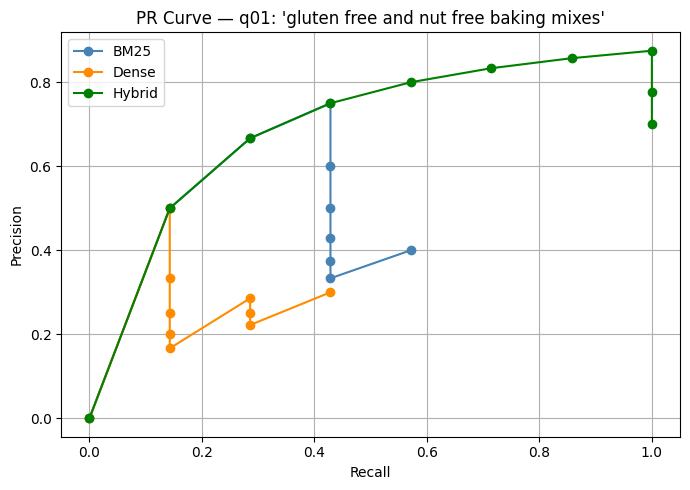

Saved: outputs/pr_curve.png


In [28]:
import matplotlib.pyplot as plt

PR_QUERY_ID = "q01"

def pr_curve_points(ranked_doc_ids, rel_map):
    total_rel = sum(1 for v in rel_map.values() if v > 0)
    points, hits = [], 0
    for k, d in enumerate(ranked_doc_ids, start=1):
        if rel_map.get(d, 0) > 0:
            hits += 1
        precision = hits / k
        recall    = hits / total_rel if total_rel > 0 else 0
        points.append((recall, precision))
    return points

rel_map = qrels_map.get(PR_QUERY_ID, {})
qtext   = queries_df[queries_df['query_id'] == PR_QUERY_ID]['query_text'].values[0]

plt.figure(figsize=(7, 5))

for run_df, label, color in [
    (run_bm25_df,   'BM25',   'steelblue'),
    (run_dense_df,  'Dense',  'darkorange'),
    (run_hybrid_df, 'Hybrid', 'green')
]:
    ranked_ids = run_df[run_df['query_id'] == PR_QUERY_ID].sort_values('rank')['doc_id'].tolist()
    pts = pr_curve_points(ranked_ids, rel_map)
    recalls    = [p[0] for p in pts]
    precisions = [p[1] for p in pts]
    plt.plot(recalls, precisions, marker='o', label=label, color=color)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"PR Curve — {PR_QUERY_ID}: '{qtext}'")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/pr_curve.png", dpi=150)
plt.show()
print("Saved: outputs/pr_curve.png")

# RAG with Groq

In [29]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.3 MB/s eta 0:00:00


In [30]:
from groq import Groq
from google.colab import userdata
import os

groq_api_key = userdata.get("GROQ_API_KEY")

if groq_api_key:
    os.environ["GROQ_API_KEY"] = groq_api_key
    print("Groq API Key set successfully.")
else:
    raise ValueError("GROQ_API_KEY not found in Colab Secrets.")

client = Groq(api_key=groq_api_key)
print("Groq client initialized.")

Groq API Key set successfully.
Groq client initialized.


# RAG Retrieval + Generation Function

In [31]:
def rag_answer(query, top_k=3):
    """
    RAG Pipeline:
    1. Retrieve top-k documents using Hybrid Search
    2. Format them as context
    3. Send to Groq LLM for grounded answer generation
    """

    # Step 1: Retrieving top-k via Hybrid Search
    retrieved = hybrid_search(query, top_k=top_k)

    # Step 2: Building context from retrieved reviews
    context_blocks = []
    for _, row in retrieved.iterrows():
        block = (
            f"[Document {row['rank']}]\n"
            f"Product: {row['product_title']}\n"
            f"Review Headline: {row['review_headline']}\n"
            f"Review: {df.loc[df['review_id'] == row['review_id'], 'review_body'].values[0]}\n"
            f"Star Rating: {row['star_rating']}/5"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)

    # Step 3: Building prompt
    system_prompt = """You are a helpful grocery product assistant.
You answer user questions based ONLY on the provided product reviews.
Be concise, specific, and always reference which product(s) you are drawing from.
If the context does not contain enough information to answer, say so honestly."""

    user_prompt = f"""User Question: {query}

Here are the top retrieved product reviews from our grocery database:

{context}

Based only on the reviews above, provide a helpful and specific answer to the user's question."""

    # Step 4: Calling Groq API
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt}
        ],
        temperature=0.3,    # low temp = more factual, less creative
        max_tokens=300
    )

    answer = response.choices[0].message.content

    return {
        "query":     query,
        "context":   retrieved[['rank', 'product_title', 'review_headline', 'rrf_score']],
        "answer":    answer
    }

# Testing RAG on Queries

In [32]:
for _, qrow in queries_df.iterrows():
    qid   = qrow['query_id']
    qtext = qrow['query_text']

    print(f"\n{'='*65}")
    print(f"  {qid}: '{qtext}'")
    print(f"{'='*65}")

    result = rag_answer(qtext, top_k=3)

    print("\n Retrieved Context:")
    print(result['context'].to_string(index=False))

    print(f"\n RAG Answer:")
    print(result['answer'])
    print()


  q01: 'gluten free and nut free baking mixes'

 Retrieved Context:
 rank                                                 product_title                                                       review_headline  rrf_score
    1                         Pamela's Products Artisan Flour Blend I've tried many gluten-free baking products and flour blends over ...   0.033333
    2 Tropical Fields Crispy Coconut Rolls with Sesame Seeds 9.3 oz                                                          Gluten free?   0.032522
    3         Namaste Foods Gluten Free Organic Perfect Flour Blend                                                            Five Stars   0.031545

 RAG Answer:
Based on the reviews, for gluten-free baking mixes, you may want to consider Pamela's Products Artisan Flour Blend (Document 1) or Namaste Foods Gluten Free Organic Perfect Flour Blend (Document 3), both of which have 5-star reviews from satisfied customers. However, neither review mentions whether these products are nu

# Interactive Query Interface

In [33]:
def query_interface(query, top_k_retrieval=5, top_k_rag=3):
    print(f"\n{'='*65}")
    print(f"  QUERY: '{query}'")
    print(f"{'='*65}")

    # Hybrid ranked results
    print(f"\nTop {top_k_retrieval} Hybrid Search Results:")
    results = hybrid_search(query, top_k=top_k_retrieval)
    for _, row in results.iterrows():
        print(f"  [{row['rank']}] {row['star_rating']} | {row['product_title'][:50]}")
        print(f"       {row['review_headline'][:60]}")
        print(f"       RRF: {row['rrf_score']:.5f} | BM25 rank: {row['bm25_rank']} | Dense rank: {row['dense_rank']}")

    # RAG answer
    print(f"\nAI Answer (grounded in top {top_k_rag} reviews):")
    result = rag_answer(query, top_k=top_k_rag)
    print(result['answer'])
    print()

# Testing with all 20 evaluation queries
for _, qrow in queries_df.iterrows():
    query_interface(qrow['query_text'])


  QUERY: 'gluten free and nut free baking mixes'

Top 5 Hybrid Search Results:
  [1] 5 | Pamela's Products Artisan Flour Blend
       I've tried many gluten-free baking products and flour blends
       RRF: 0.03333 | BM25 rank: 1 | Dense rank: 1
  [2] 1 | Tropical Fields Crispy Coconut Rolls with Sesame S
       Gluten free?
       RRF: 0.03252 | BM25 rank: 3 | Dense rank: 2
  [3] 5 | Namaste Foods Gluten Free Organic Perfect Flour Bl
       Five Stars
       RRF: 0.03154 | BM25 rank: 2 | Dense rank: 7
  [4] 5 | Pamela's Products Amazing Wheat Free & Gluten-free
       Gluten Free bread can satisfy the bread lover.
       RRF: 0.02783 | BM25 rank: 10 | Dense rank: 16
  [5] 5 | Pillsbury Funfetti Gluten Free Premium Cake & Cupc
       Best gluten free cake mix cake I've had
       RRF: 0.02699 | BM25 rank: 21 | Dense rank: 10

AI Answer (grounded in top 3 reviews):
Based on the provided reviews, two products are suitable for gluten-free baking: Pamela's Products Artisan Flour Blend (Do

In [40]:
from ipywidgets import widgets
from IPython.display import display, clear_output

# Input box
query_input = widgets.Text(
    placeholder="e.g. best protein bars for gym",
    description="Query:",
    layout=widgets.Layout(width="500px")
)

# Dropdown for method
method_dropdown = widgets.Dropdown(
    options=["Hybrid + RAG", "BM25 only", "Dense only", "Hybrid only"],
    value="Hybrid + RAG",
    description="Method:",
)

# Button
run_button = widgets.Button(
    description="Search",
    button_style="primary"
)

# Output area
output_area = widgets.Output()

def on_search_clicked(b):
    with output_area:
        clear_output()
        query = query_input.value.strip()
        method = method_dropdown.value

        if not query:
            print("Please enter a query.")
            return

        if method == "BM25 only":
            display(bm25_search(query, top_k=5))

        elif method == "Dense only":
            display(dense_search(query, top_k=5))

        elif method == "Hybrid only":
            display(hybrid_search(query, top_k=5))

        elif method == "Hybrid + RAG":
            print("Top 5 Hybrid Results:")
            display(hybrid_search(query, top_k=5))
            print("\nRAG Answer:")
            result = rag_answer(query, top_k=3)
            print(result["answer"])

run_button.on_click(on_search_clicked)

display(query_input, method_dropdown, run_button, output_area)

Text(value='', description='Query:', layout=Layout(width='500px'), placeholder='e.g. best protein bars for gym…

Dropdown(description='Method:', options=('Hybrid + RAG', 'BM25 only', 'Dense only', 'Hybrid only'), value='Hyb…

Button(button_style='primary', description='Search', style=ButtonStyle())

Output()

# Saving

In [ ]:
# Saving a sample of RAG outputs for outputs folder
rag_outputs = []
for _, qrow in queries_df.iterrows():
    result = rag_answer(qrow['query_text'], top_k=3)
    top_docs = result['context']['product_title'].tolist()
    rag_outputs.append({
        'query_id':  qrow['query_id'],
        'query':     qrow['query_text'],
        'top_doc_1': top_docs[0] if len(top_docs) > 0 else '',
        'top_doc_2': top_docs[1] if len(top_docs) > 1 else '',
        'top_doc_3': top_docs[2] if len(top_docs) > 2 else '',
        'rag_answer': result['answer']
    })

pd.DataFrame(rag_outputs).to_csv("outputs/rag_outputs.csv", index=False)
print(f"RAG outputs saved: {len(rag_outputs)} queries")

RAG outputs saved: 20 queries
